# Renewable energy

In [2]:
SolarP = 23000  # [TW]
DemandP = 16    # [TW]
WindPmin = 25   # [TW]
WindPmax = 75   # [TW]
OTECPmin  = 3   # [TW]
OTECPmax  = 11  # [TW]
BioPmin   = 2   # [TW]
BioPmax   = 6   # [TW]
HydroPmin = 3   # [TW]
HydroPmax = 4   # [TW]
GeothermalPmin = 0.3   # [TW]
GeothermalPmax = 2     # [TW]
WavePmin = 0.2   # [TW]
WavePmax = 2     # [TW]
TidalP = 0.3     # [TW]

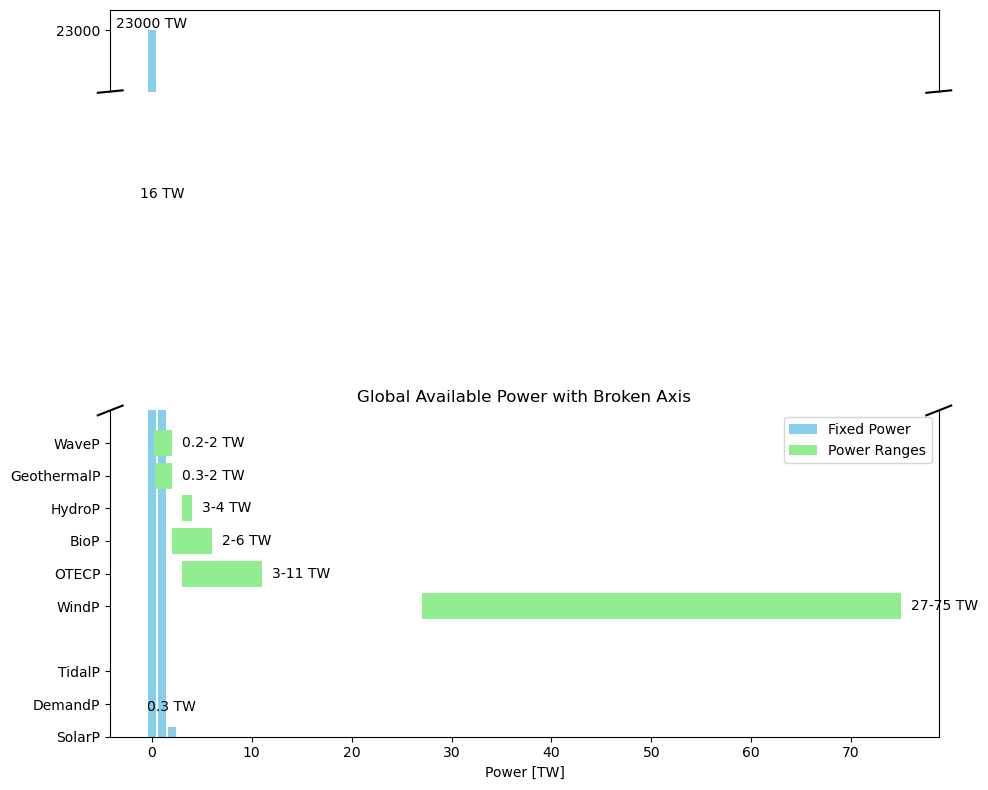

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data
fixed_power = {
    "SolarP": 23000,  # Outlier
    "DemandP": 16,
    "TidalP": 0.3
}

range_power = {
    "WindP": [27, 75],
    "OTECP": [3, 11],
    "BioP": [2, 6],
    "HydroP": [3, 4],
    "GeothermalP": [0.3, 2],
    "WaveP": [0.2, 2]
}

# Plot setup
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1, 4]}, figsize=(10, 8))

# Fixed values for plotting
fixed_positions = np.arange(len(fixed_power))
range_positions = np.arange(len(range_power)) + len(fixed_power) + 1

# Top axis for SolarP outlier
ax1.bar(fixed_positions, fixed_power.values(), color='skyblue')
ax1.set_ylim(20000, 24000)  # Focus on the large outlier range
ax1.set_yticks([23000])
ax1.spines['bottom'].set_visible(False)
ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
ax1.text(fixed_positions[0], 23000 + 100, "23000 TW", ha='center', fontsize=10)

# Bottom axis for the smaller values
ax2.bar(fixed_positions, fixed_power.values(), color='skyblue')
for i, key in enumerate(fixed_power.keys()):
    if key != "SolarP":
        ax2.text(fixed_positions[i], fixed_power[key] + 0.5, f"{fixed_power[key]} TW", ha='center', fontsize=10)

# Plot range power
range_labels = list(range_power.keys())
range_mins = [v[0] for v in range_power.values()]
range_maxs = [v[1] for v in range_power.values()]
range_widths = [max_val - min_val for min_val, max_val in zip(range_mins, range_maxs)]

ax2.barh(range_positions, range_widths, left=range_mins, color='lightgreen')
for i, label in enumerate(range_labels):
    ax2.text(range_maxs[i] + 1, range_positions[i], f"{range_mins[i]}-{range_maxs[i]} TW", va='center', fontsize=10)

ax2.set_ylim(0, len(fixed_power) + len(range_power) + 1)
ax2.set_yticks(np.concatenate([fixed_positions, range_positions]))
ax2.set_yticklabels(list(fixed_power.keys()) + range_labels)

# Decorations
ax2.set_xlabel("Power [TW]")
ax2.spines['top'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.tick_params(labeltop=False)  # Disable top labels
ax2.set_title("Global Available Power with Broken Axis")
ax2.legend(["Fixed Power", "Power Ranges"], loc="upper right")

# Broken axis marks
d = 0.015  # Marker size
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # Top diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Bottom diagonal

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Top diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom diagonal

plt.tight_layout()
plt.show()

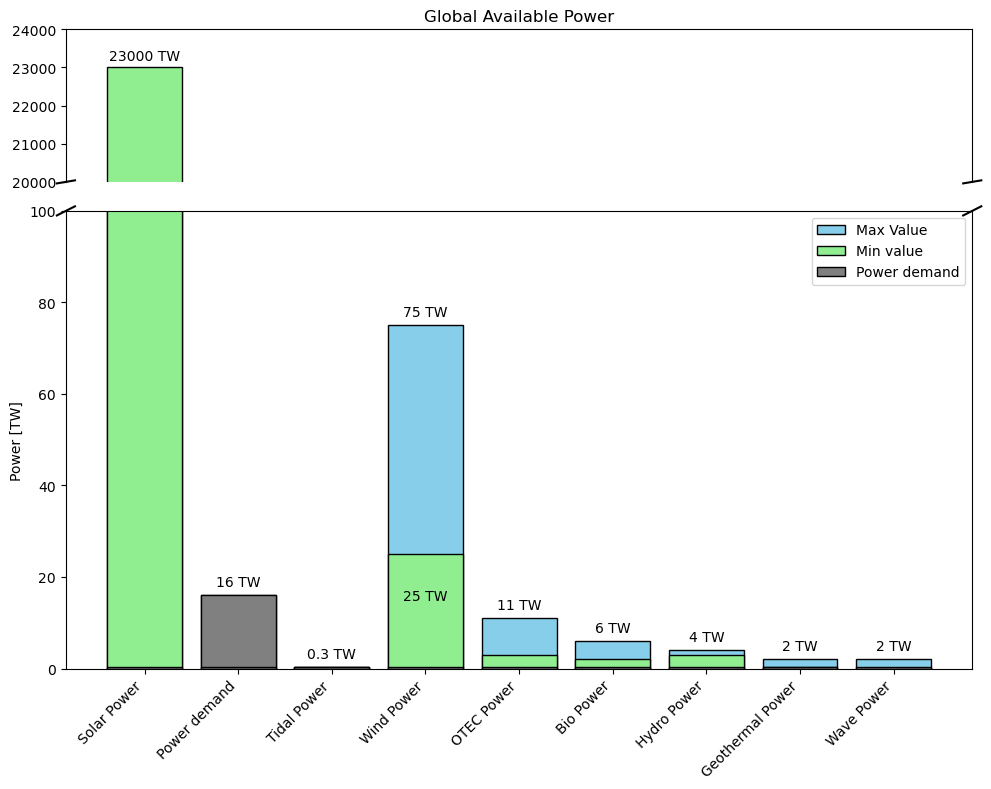

In [121]:
import matplotlib.pyplot as plt
import numpy as np

# Data
labels = [
    "Solar Power", "Power demand",  "Tidal Power", "Wind Power", "OTEC Power",
    "Bio Power", "Hydro Power", "Geothermal Power", "Wave Power"
]
fixed_power = [23000, 16, 0.3]  # Fixed values
range_power = {
    "Wind Power": [25, 75],
    "OTEC Power": [3, 11],
    "Bio Power": [2, 6],
    "Hydro Power": [3, 4],
    "Geothermal Power": [0.3, 2],
    "Wave Power": [0.2, 2],
}

# Combine fixed values and ranges
min_values = fixed_power + [v[0] for v in range_power.values()]
max_values = fixed_power + [v[1] for v in range_power.values()]

# Bar positions
positions = np.arange(len(labels))

# Plot setup with broken axis
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8), gridspec_kw={'height_ratios': [1, 3]})

bar_colors = ["lightgreen" if label != "Power demand" else "grey" for label in labels]

# Top axis for large SolarP value
ax1.bar(positions, max_values, color=bar_colors, edgecolor='black')
ax1.set_ylim(20000, 24000)
ax1.spines['bottom'].set_visible(False)
ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# Add labels for top axis
ax1.text(0, 23000 + 200, f"{max_values[0]} TW", ha='center', fontsize=10)


# Bottom axis for smaller values
ax2.bar(positions, max_values, color="skyblue", edgecolor='black', label="Max Value")
ax2.bar(positions, min_values, color=bar_colors, edgecolor='black', label="Min value")
ax2.bar(positions, min_values[2], color="grey", edgecolor='black', label="Power demand")

ax2.set_ylim(0, 100)  # Focus on smaller range
ax2.set_xticks(positions)
ax2.set_xticklabels(labels, rotation=45, ha='right')

# Add labels for bottom axis
for i, (min_val, max_val) in enumerate(zip(min_values, max_values)):
    if i != 0:  # Skip SolarP for the bottom axis
        ax2.text(i, max_val + 2, f"{max_val} TW", ha='center', fontsize=10)
        if min_val>20:
            ax2.text(i, min_val - 10, f"{min_val} TW", ha='center', fontsize=10)

# Decorations
ax2.set_ylabel("Power [TW]")
ax1.set_title("Global Available Power")
ax2.legend(loc="upper right")

# Diagonal lines for broken axis
d = 0.01  # Size of the diagonal lines
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # Top diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Bottom diagoanal

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Top diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom diagonal

plt.tight_layout()
plt.savefig("figures/solar report/energymap.png")
plt.show()